In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [106]:
# Read all py_res_*.csv files
py_res_files = glob.glob('py_res_*.csv')
py_res_dfs = [pd.read_csv(file) for file in py_res_files]
for i, file in enumerate(py_res_files):
    py_res_dfs[i]['num_cpus'] = file.split('_')[2].split('.')[0]

# Concatenate all dataframes
py_res = pd.concat(py_res_dfs)


# Read all rs_res_*.csv files
rs_res_files = glob.glob('rs_res_*.csv')
rs_res_dfs = [pd.read_csv(file) for file in rs_res_files]
for i, file in enumerate(rs_res_files):
    rs_res_dfs[i]['num_cpus'] = file.split('_')[2].split('.')[0]

# Concatenate all dataframes
rs_res = pd.concat(rs_res_dfs)

# Sort by num_cpus
py_res = py_res.sort_values(by='num_cpus')
rs_res = rs_res.sort_values(by='num_cpus')

py_res['tottime'] = py_res['buildtime'] + py_res['querytime']
rs_res['tottime'] = rs_res['buildtime'] + rs_res['querytime']

# Extract nprobe from params
py_res['nprobe'] = py_res['params'].str.extract(r'nprobe=(\d+)').astype(int)
rs_res['nprobe'] = rs_res['params'].str.extract(r'nprobe=(\d+)').astype(int)

print(len(py_res))
py_res.head()

180


,size,algo,modelingtime,encdatabasetime,encqueriestime,buildtime,querytime,params,recall,num_cpus,tottime,nprobe
0,100M,lmi,0.0,0.0,0.0,5460.74516,843.644745,t1-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.950267,16,6304.389904,22
29,100M,lmi,0.0,0.0,0.0,5460.74516,740.857609,t1-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.948377,16,6201.602769,21
27,100M,lmi,0.0,0.0,0.0,5460.74516,881.900988,t1-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.953627,16,6342.646148,24
26,100M,lmi,0.0,0.0,0.0,5460.74516,426.317238,t1-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.918660,16,5887.062397,12
25,100M,lmi,0.0,0.0,0.0,5460.74516,593.893531,t1-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.928183,16,6054.638691,14


In [107]:
print(len(rs_res))
rs_res.head()

180


,size,algo,modelingtime,encdatabasetime,encqueriestime,buildtime,querytime,params,recall,num_cpus,tottime,nprobe
29,100M,rust-lmi-task1,0.0,0.0,0.0,7837.460409,570.213223,rust-lmi-task1-ds=100M-ep=15-lr=0.00098-sample...,0.971423,16,8407.673632,22
1,100M,rust-lmi-task1,0.0,0.0,0.0,7837.460409,364.419610,rust-lmi-task1-ds=100M-ep=15-lr=0.00098-sample...,0.954007,16,8201.880019,13
2,100M,rust-lmi-task1,0.0,0.0,0.0,7837.460409,39.893955,rust-lmi-task1-ds=100M-ep=15-lr=0.00098-sample...,0.604517,16,7877.354364,1
3,100M,rust-lmi-task1,0.0,0.0,0.0,7837.460409,503.406739,rust-lmi-task1-ds=100M-ep=15-lr=0.00098-sample...,0.967450,16,8340.867147,19
4,100M,rust-lmi-task1,0.0,0.0,0.0,7837.460409,340.420530,rust-lmi-task1-ds=100M-ep=15-lr=0.00098-sample...,0.950183,16,8177.880938,12


In [108]:
# Group by num_cpus
py_res_grouped = py_res.groupby('num_cpus')
rs_res_grouped = rs_res.groupby('num_cpus')

In [109]:
py_res_grouped['querytime'].mean()

num_cpus
16    582.964779
32    981.611321
48    341.345504
64    227.494766
80    243.177927
96    255.595494
Name: querytime, dtype: float64

In [110]:
rs_res_grouped['querytime'].mean()

num_cpus
16    413.017937
32    208.493378
48    139.516461
64    103.639309
80     82.904885
96     69.297696
Name: querytime, dtype: float64

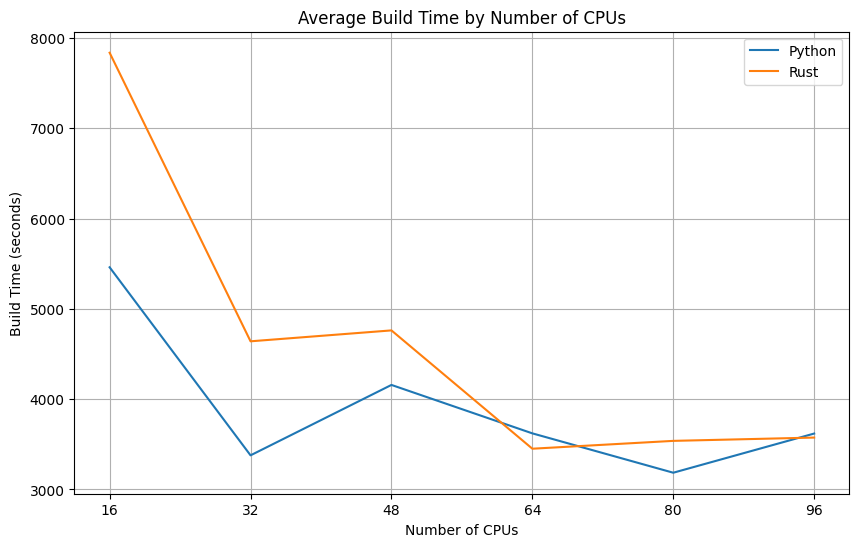

In [112]:
# Convert grouped data to DataFrame for plotting
py_buildtime_mean = py_res_grouped['buildtime'].mean().reset_index()
rs_buildtime_mean = rs_res_grouped['buildtime'].mean().reset_index()

# Plot the average buildtime grouped by num_cpus in a single line chart
plt.figure(figsize=(10, 6))
sns.lineplot(x='num_cpus', y='buildtime', data=py_buildtime_mean, label='Python')
sns.lineplot(x='num_cpus', y='buildtime', data=rs_buildtime_mean, label='Rust')
plt.title('Average Build Time by Number of CPUs')
plt.xlabel('Number of CPUs')
plt.ylabel('Build Time (seconds)')
plt.grid(True)
plt.legend()
plt.show()


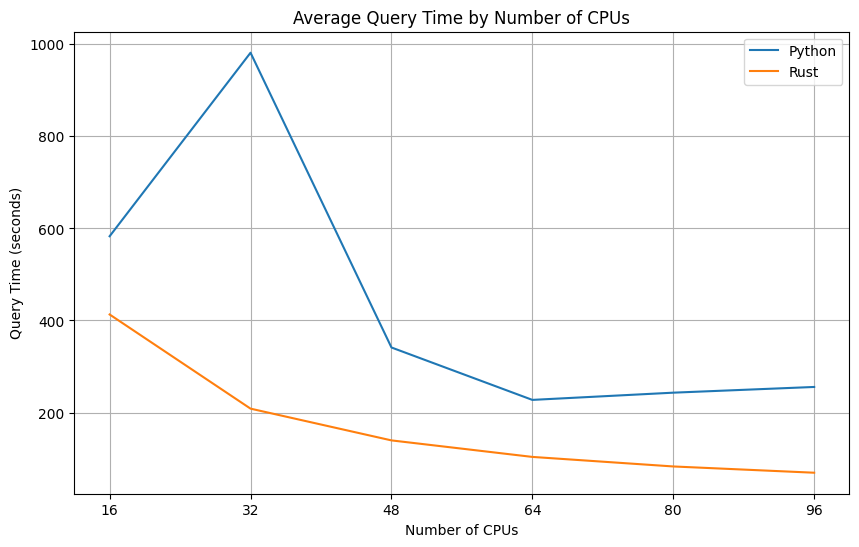

In [113]:
# Convert grouped data to DataFrame for plotting
py_querytime_mean = py_res_grouped['querytime'].mean().reset_index()
rs_querytime_mean = rs_res_grouped['querytime'].mean().reset_index()

# Plot the average querytime grouped by num_cpus in a single line chart
plt.figure(figsize=(10, 6))
sns.lineplot(x='num_cpus', y='querytime', data=py_querytime_mean, label='Python')
sns.lineplot(x='num_cpus', y='querytime', data=rs_querytime_mean, label='Rust')
plt.title('Average Query Time by Number of CPUs')
plt.xlabel('Number of CPUs')
plt.ylabel('Query Time (seconds)')
plt.grid(True)
plt.legend()
plt.show()


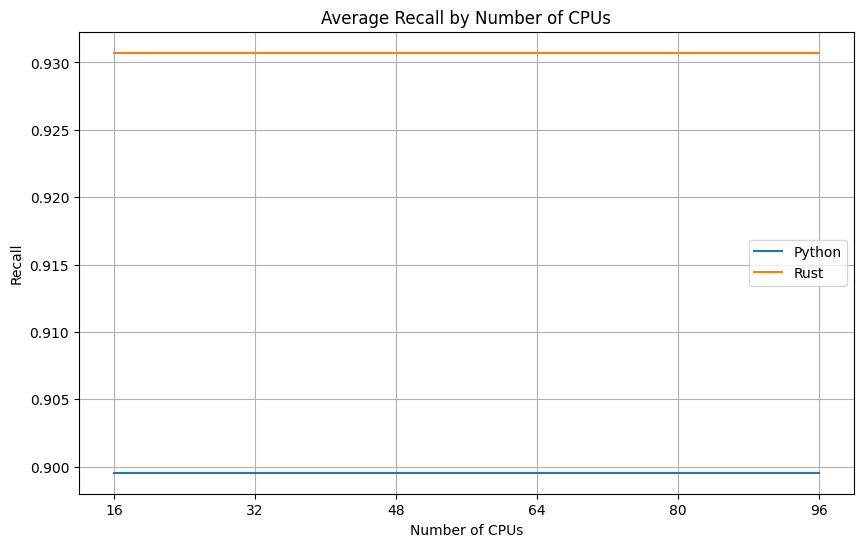

In [114]:
# Convert grouped data to DataFrame for plotting
py_recall_mean = py_res_grouped['recall'].mean().reset_index()
rs_recall_mean = rs_res_grouped['recall'].mean().reset_index()

# Plot the average querytime grouped by num_cpus in a single line chart
plt.figure(figsize=(10, 6))
sns.lineplot(x='num_cpus', y='recall', data=py_recall_mean, label='Python')
sns.lineplot(x='num_cpus', y='recall', data=rs_recall_mean, label='Rust')
plt.title('Average Recall by Number of CPUs')
plt.xlabel('Number of CPUs')
plt.ylabel('Recall')
plt.grid(True)
plt.legend()
plt.show()


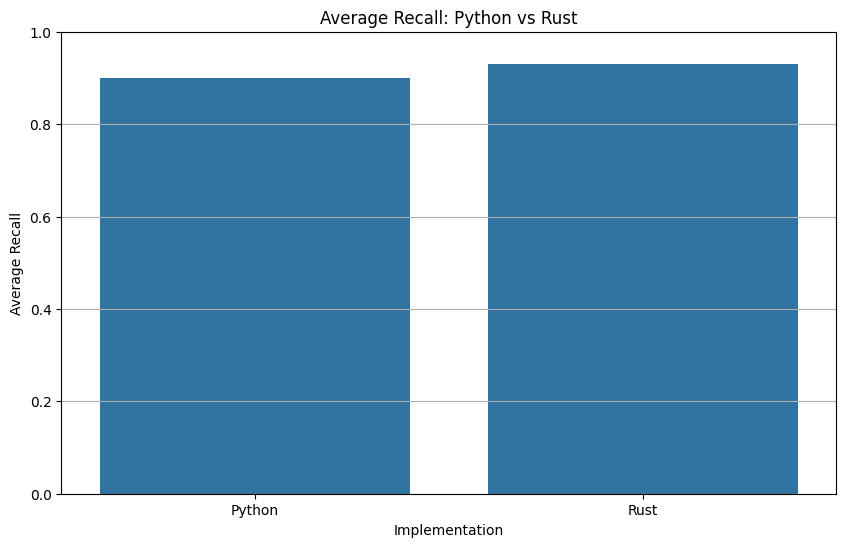

In [115]:
# Calculate the overall average recall for Python and Rust
py_overall_recall = py_res['recall'].mean()
rs_overall_recall = rs_res['recall'].mean()

# Create a DataFrame for the bar plot
recall_data = pd.DataFrame({
    'Implementation': ['Python', 'Rust'],
    'Average Recall': [py_overall_recall, rs_overall_recall]
})

# Plot the average recall as a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Implementation', y='Average Recall', data=recall_data)
plt.title('Average Recall: Python vs Rust')
plt.xlabel('Implementation')
plt.ylabel('Average Recall')
plt.grid(True, axis='y')
plt.ylim(0, 1)  # Set y-axis from 0 to 1 for recall values
plt.show()


Text(0.5, 1.0, 'Average Total Time by Number of CPUs')

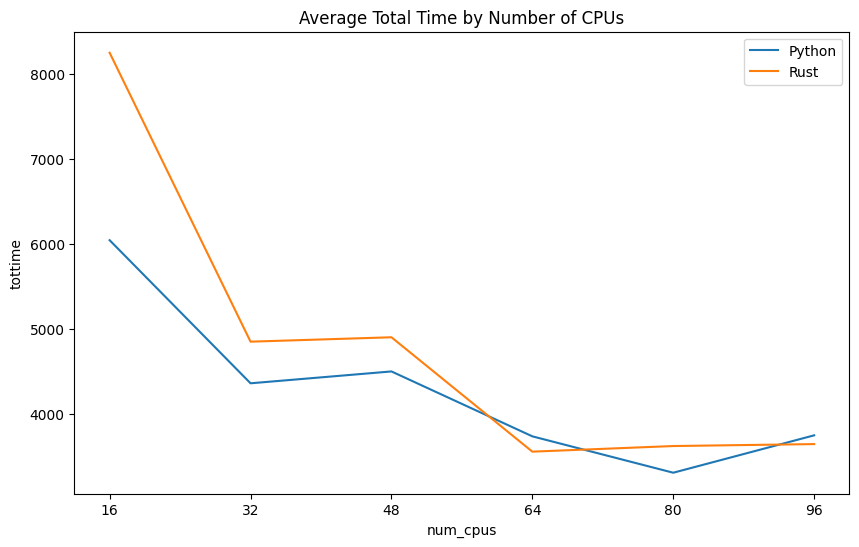

In [48]:
# Plot the average querytime + buildtime grouped by num_cpus in a single line chart
py_total_time_mean = py_res_grouped['tottime'].mean().reset_index()
rs_total_time_mean = rs_res_grouped['tottime'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='num_cpus', y='tottime', data=py_total_time_mean, label='Python')
sns.lineplot(x='num_cpus', y='tottime', data=rs_total_time_mean, label='Rust')
plt.title('Average Total Time by Number of CPUs')

